C:\Users\ALIF\AppData\Local\Temp\ipykernel_13200\2954321883.py:15: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(img))
C:\Users\ALIF\AppData\Local\Temp\ipykernel_13200\2954321883.py:15: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(img))
C:\Users\ALIF\AppData\Local\Temp\ipykernel_13200\2954321883.py:25: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axs[1, 0].hist(img.ravel(), 256, [0, 256])
C:\Users\ALIF\AppData\Local\Temp\ipykernel_13200\2954321883.py:31: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axs[1, 1].hist(negatif.ravel(), 256, [0, 256])
C:\Users\ALIF\AppData\Local\Temp\ipykernel_13200\2954321883.py:37: MatplotlibDeprecationWarning: Passing the range parameter of hist(

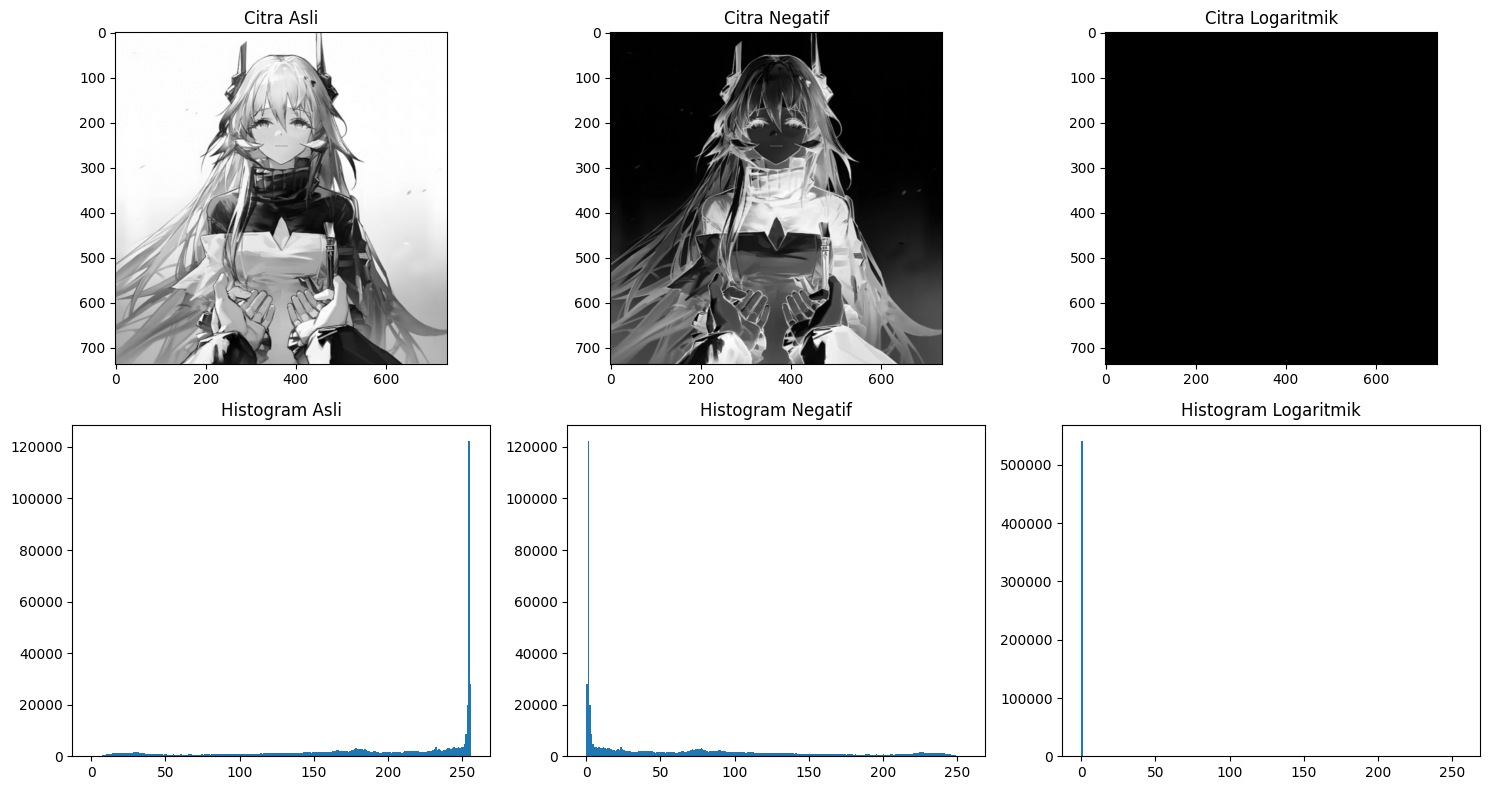

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Baca citra grayscale (Sesuaikan nama file dengan yang ada di direktori Anda)
img = cv2.imread('Image.jpg', cv2.IMREAD_GRAYSCALE)

if img is not None:
    # 2. Terapkan rumus:
    # a. Negatif: G = 255 - F
    negatif = 255 - img

    # b. Logaritmik: G = c * log(1+F)
    # Konversi ke float64 untuk menghindari overflow (nilai > 255) dan divide by zero
    img_float = img.astype(np.float64)
    c = 255 / np.log(1 + np.max(img_float))
    logaritmik = c * np.log(1 + img_float)
    
    # Kembalikan tipe data ke uint8 agar dapat ditampilkan sebagai gambar
    logaritmik = np.array(logaritmik, dtype=np.uint8)

    # 3. Tampilkan keempat gambar dan histogramnya
    fig, axs = plt.subplots(2, 3, figsize=(15, 8))

    # Citra Asli
    axs[0, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
    axs[0, 0].set_title('Citra Asli')
    # Menggunakan bins dan range untuk menghindari MatplotlibDeprecationWarning
    axs[1, 0].hist(img.ravel(), bins=256, range=[0, 256])
    axs[1, 0].set_title('Histogram Asli')

    # Citra Negatif
    axs[0, 1].imshow(negatif, cmap='gray', vmin=0, vmax=255)
    axs[0, 1].set_title('Citra Negatif')
    axs[1, 1].hist(negatif.ravel(), bins=256, range=[0, 256])
    axs[1, 1].set_title('Histogram Negatif')

    # Citra Logaritmik
    axs[0, 2].imshow(logaritmik, cmap='gray', vmin=0, vmax=255)
    axs[0, 2].set_title('Citra Logaritmik')
    axs[1, 2].hist(logaritmik.ravel(), bins=256, range=[0, 256])
    axs[1, 2].set_title('Histogram Logaritmik')

    plt.tight_layout()
    plt.show()
else:
    print("Gambar tidak ditemukan. Harap pastikan file Image.jpg berada di folder yang sama.")